# Import Necessary Libraries

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import PIL

# No GPU for tensorflow to use
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [47]:
print("Num GPUs Available:", len(tf.config.experimental.list_physical_devices("GPU")))
print("Devices:", tf.config.experimental.list_physical_devices())

Num GPUs Available: 0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [48]:
# Load The Dataset

In [49]:
import pathlib

directory_name = 'data'
data_dir = pathlib.Path(directory_name).resolve()

In [50]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

624


# Loading The Dataset

In [51]:
batch_size = 32
img_height = 180
img_width = 180

In [52]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 624 files belonging to 4 classes.
Using 500 files for training.
Found 624 files belonging to 4 classes.
Using 124 files for validation.


In [53]:
class_names = train_ds.class_names
print(class_names)


['balut', 'bugok', 'empty', 'penoy']


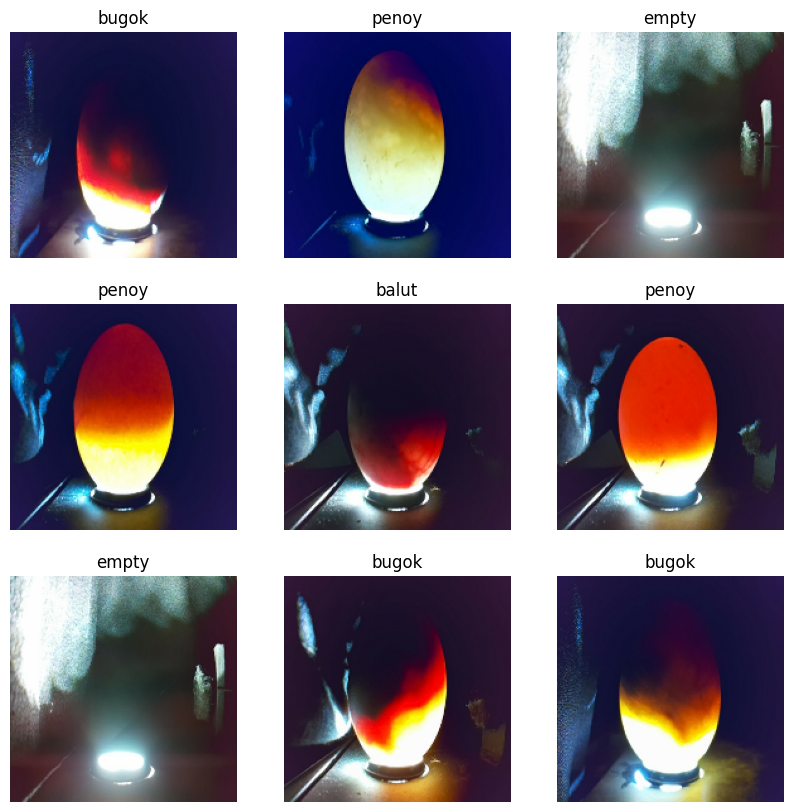

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [55]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [56]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [57]:
# Standardize the data
normalization_layer = layers.Rescaling(1./255)

normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


# Creating The Model

In [58]:
num_classes = len(class_names)
model = Sequential([
    keras.Input(shape=(img_height, img_width, 3)),  # Explicit input layer
    layers.Rescaling(1./255),  # No need for input_shape here
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])


In [59]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [60]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,156 (15.22 MB)

 Trainable params: 3,989,156 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

# Train The Model

# Data Augmentation
When there are a small number of training examples, the model sometimes learns from noises or unwanted details from training examples—to an extent that it negatively impacts the performance of the model on new examples. This phenomenon is known as overfitting. It means that the model will have a difficult time generalizing on a new dataset (Source: Tensorflow).

In [62]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

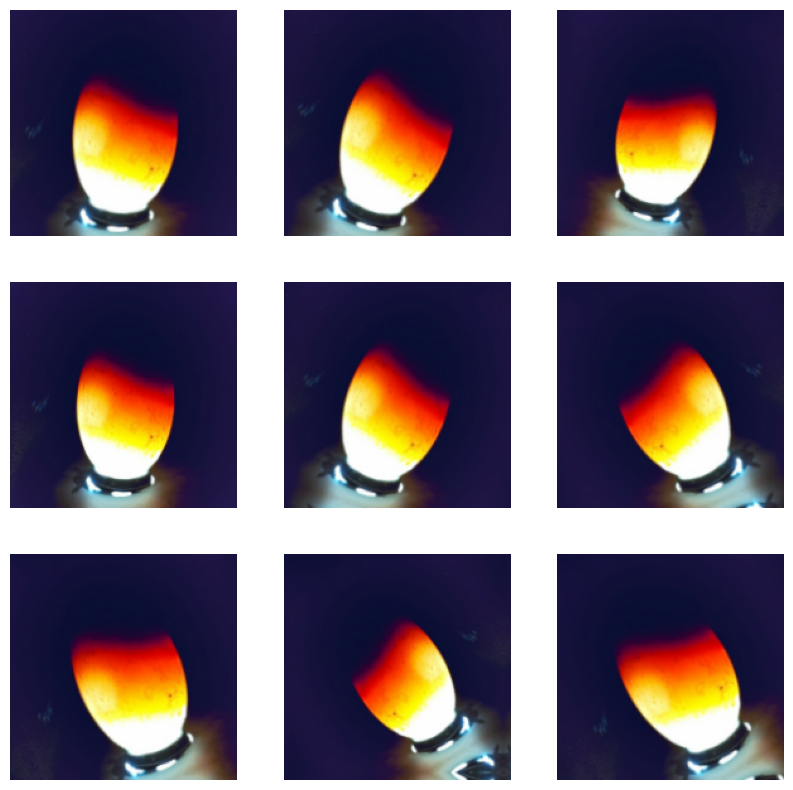

In [63]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")


In [64]:
# With Dropout
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])


In [65]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [66]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,156 (15.22 MB)

 Trainable params: 3,989,156 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
epochs=15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 366ms/step - accuracy: 0.5255 - loss: 1.1281 - val_accuracy: 0.7661 - val_loss: 0.6070
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 325ms/step - accuracy: 0.8103 - loss: 0.5186 - val_accuracy: 0.8629 - val_loss: 0.3985
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - accuracy: 0.8505 - loss: 0.3881 - val_accuracy: 0.8871 - val_loss: 0.3325
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 362ms/step - accuracy: 0.8853 - loss: 0.2738 - val_accuracy: 0.8629 - val_loss: 0.3480
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 429ms/step - accuracy: 0.9026 - loss: 0.2669 - val_accuracy: 0.8952 - val_loss: 0.3076
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 413ms/step - accuracy: 0.9174 - loss: 0.2091 - val_accuracy: 0.9113 - val_loss: 0.2433
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 404ms/step - accuracy: 0.9420 - loss: 0.1722 - val_accuracy: 0.9274 - val_loss: 0.2082
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 403ms/step - accuracy: 0.9370 - loss: 0.1617 - val_accuracy: 0

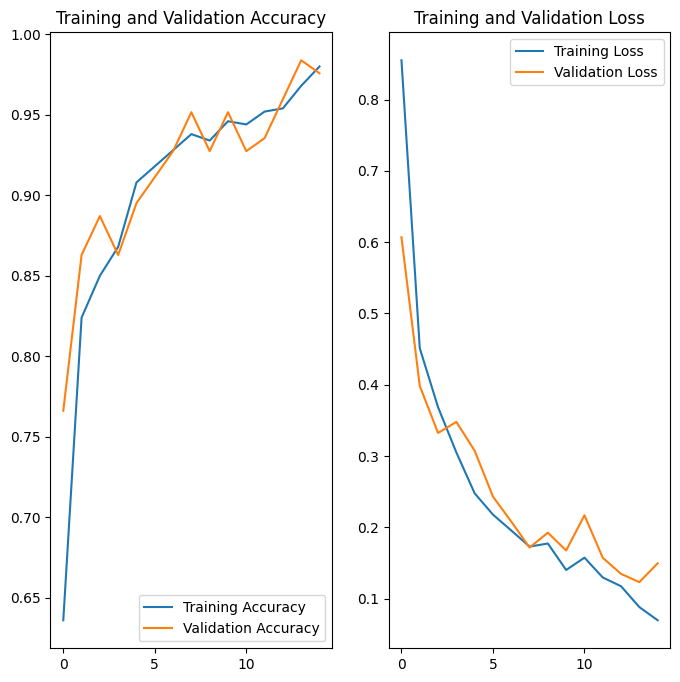

In [68]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [69]:
plt.savefig("training.jpg")

<Figure size 640x480 with 0 Axes>

In [70]:
import os

# Define the test images directory
test_dir = pathlib.Path("tests")

# Loop through all images in the test directory
for image_path in test_dir.glob("*.jpg"):  # Adjust for different formats if needed
    img = tf.keras.utils.load_img(image_path, target_size=(img_height, img_width))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create a batch

    # Make prediction
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    # Print results
    print(
        "Image: {}\nPredicted: {} with {:.2f}% confidence\n".format(
            image_path.name, class_names[np.argmax(score)], 100 * np.max(score)
        )
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Image: bugok_image_20250415_113637_13.jpg
Predicted: bugok with 95.69% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Image: balut_image_20250415_112632_140.jpg
Predicted: balut with 99.05% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Image: penoy_image_20250415_174246_1.jpg
Predicted: penoy with 99.97% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Image: penoy_image_20250415_174358_17.jpg
Predicted: penoy with 99.93% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Image: balut_image_20250415_113134_178.jpg
Predicted: balut with 99.71% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Image: bugok_image_20250415_113725_21.jpg
Predicted: bugok with 95.68% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Image: bugok_image_20250415_113550_1.jpg
Predicted: bugok with 99.64% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Image: penoy_image_20250415_174626_48.jpg
Predicted: penoy with 99.92% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms

# Save The Model

In [72]:
from tensorflow.keras.models import load_model

model.save(os.path.join('models','balut_classifier4.h5'))

# Try The Model

In [73]:
loaded_model = load_model(os.path.join('models','balut_classifier3.h5'))

In [74]:
import os

# Define the test images directory
test_dir = pathlib.Path("tests")

# Loop through all images in the test directory
for image_path in test_dir.glob("*.jpg"):  # Adjust for different formats if needed
    img = tf.keras.utils.load_img(image_path, target_size=(img_height, img_width))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create a batch

    # Make prediction
    predictions = loaded_model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    # Print results
    print(
        "Image: {}\nPredicted: {} with {:.2f}% confidence\n".format(
            image_path.name, class_names[np.argmax(score)], 100 * np.max(score)
        )
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Image: bugok_image_20250415_113637_13.jpg
Predicted: bugok with 94.41% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Image: balut_image_20250415_112632_140.jpg
Predicted: balut with 62.90% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Image: penoy_image_20250415_174246_1.jpg
Predicted: penoy with 86.59% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Image: penoy_image_20250415_174358_17.jpg
Predicted: penoy with 73.65% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Image: balut_image_20250415_113134_178.jpg
Predicted: bugok with 68.32% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Image: bugok_image_20250415_113725_21.jpg
Predicted: bugok with 91.69% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Image: bugok_image_20250415_113550_1.jpg
Predicted: bugok with 95.26% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Image: penoy_image_20250415_174626_48.jpg
Predicted: bugok with 98.72% confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms